In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
DATA_PATH = "../data/raw/ai4i2020.csv"
df = pd.read_csv(DATA_PATH)

In [2]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
# Temperature difference
df["temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

# Mechanical power in watts
df["power_w"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2 * np.pi / 60
)

# Tool wear × torque
df["wear_torque"] = (
    df["Tool wear [min]"]
    * df["Torque [Nm]"]
)

# Type-specific overstrain limits
strain_limits = {
    "L": 11000,
    "M": 12000,
    "H": 13000
}

df["strain_limit"] = df["Type"].map(strain_limits)

print(df[
    [
        "Type",
        "temp_diff",
        "power_w",
        "wear_torque",
        "strain_limit"
    ]
].head())

  Type  temp_diff      power_w  wear_torque  strain_limit
0    M       10.5  6951.590560          0.0         12000
1    L       10.5  6826.722724        138.9         11000
2    L       10.4  7749.387543        247.0         11000
3    L       10.4  5927.504659        276.5         11000
4    L       10.5  5897.816608        360.0         11000


In [4]:
df["predicted_HDF"] = (
    (df["temp_diff"] < 8.6)
    &
    (df["Rotational speed [rpm]"] < 1380)
)

df["predicted_HDF"].value_counts()

predicted_HDF
False    9885
True      115
Name: count, dtype: int64

In [5]:
hdf_match = df["predicted_HDF"] == df["HDF"]

print("HDF matching rows:", hdf_match.sum())
print("HDF mismatching rows:", (~hdf_match).sum())

print(
    "HDF match percentage:",
    round(hdf_match.mean() * 100, 4),
    "%"
)

HDF matching rows: 10000
HDF mismatching rows: 0
HDF match percentage: 100.0 %


In [6]:
hdf_mismatches = df.loc[
    ~hdf_match,
    [
        "UDI",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "HDF",
        "predicted_HDF"
    ]
]

hdf_mismatches

,UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],HDF,predicted_HDF


In [7]:
df["predicted_PWF"] = (
    (df["power_w"] < 3500)
    |
    (df["power_w"] > 9000)
)

df["predicted_PWF"].value_counts()

predicted_PWF
False    9905
True       95
Name: count, dtype: int64

In [8]:
pwf_match = df["predicted_PWF"] == df["PWF"]

print("PWF matching rows:", pwf_match.sum())
print("PWF mismatching rows:", (~pwf_match).sum())

print(
    "PWF match percentage:",
    round(pwf_match.mean() * 100, 4),
    "%"
)

PWF matching rows: 10000
PWF mismatching rows: 0
PWF match percentage: 100.0 %


In [9]:
df["predicted_OSF"] = (
    df["wear_torque"] > df["strain_limit"]
)

df["predicted_OSF"].value_counts()

predicted_OSF
False    9902
True       98
Name: count, dtype: int64

In [10]:
osf_match = df["predicted_OSF"] == df["OSF"]

print("OSF matching rows:", osf_match.sum())
print("OSF mismatching rows:", (~osf_match).sum())

print(
    "OSF match percentage:",
    round(osf_match.mean() * 100, 4),
    "%"
)

OSF matching rows: 10000
OSF mismatching rows: 0
OSF match percentage: 100.0 %


In [11]:
df["rule_any"] = (
    df["predicted_HDF"]
    |
    df["predicted_PWF"]
    |
    df["predicted_OSF"]
)

print("Rows triggered by at least one documented rule:",
      df["rule_any"].sum())

print("Actual machine failures:",
      df["Machine failure"].sum())

Rows triggered by at least one documented rule: 287
Actual machine failures: 339


In [12]:
y_true = df["Machine failure"]
y_rule = df["rule_any"].astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_rule,
    labels=[0, 1]
).ravel()

precision = precision_score(
    y_true,
    y_rule,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_rule,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_rule,
    zero_division=0
)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print("\nPrecision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1       :", round(f1, 4))

True Negatives : 9661
False Positives: 0
False Negatives: 52
True Positives  : 287

Precision: 1.0
Recall   : 0.8466
F1       : 0.9169


In [13]:
actual_failures = df["Machine failure"].sum()
rule_detected_failures = (
    (df["Machine failure"] == 1)
    & (df["rule_any"])
).sum()

coverage = rule_detected_failures / actual_failures * 100

print("Actual failures:", actual_failures)
print("Rule-covered failures:", rule_detected_failures)
print("Failure coverage:", round(coverage, 2), "%")

Actual failures: 339
Rule-covered failures: 287
Failure coverage: 84.66 %


In [14]:
mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df["any_mode_flag"] = (
    df[mode_cols].sum(axis=1) > 0
)

mode_present_target_zero = (
    df["any_mode_flag"]
    & (df["Machine failure"] == 0)
)

failure_without_mode = (
    (df["Machine failure"] == 1)
    & (~df["any_mode_flag"])
)

print(
    "Mode present + Machine failure = 0:",
    mode_present_target_zero.sum()
)

print(
    "Machine failure = 1 + no mode:",
    failure_without_mode.sum()
)

Mode present + Machine failure = 0: 18
Machine failure = 1 + no mode: 9


In [15]:
unexplained_failures = df.loc[
    failure_without_mode,
    [
        "UDI",
        "Product ID",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "temp_diff",
        "power_w",
        "wear_torque",
        "Machine failure",
        *mode_cols
    ]
]

print(
    "Rule-unexplained machine failures:",
    len(unexplained_failures)
)

unexplained_failures

Rule-unexplained machine failures: 9


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff,power_w,wear_torque,Machine failure,TWF,HDF,PWF,OSF,RNF
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,11.1,6811.266088,1808.0,1,0,0,0,0,0
2749,2750,M17609,M,299.7,309.2,1685,28.9,179,9.5,5099.485555,5173.1,1,0,0,0,0,0
4044,4045,M18904,M,301.9,310.9,1419,47.7,20,9.0,7088.092761,954.0,1,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,8.2,6666.543387,4524.8,1,0,0,0,0,0
5536,5537,M20396,M,302.3,311.8,1363,54.0,119,9.5,7707.583416,6426.0,1,0,0,0,0,0
5941,5942,L53121,L,300.6,310.7,1438,48.5,78,10.1,7303.469881,3783.0,1,0,0,0,0,0
6478,6479,L53658,L,300.5,309.8,1663,29.1,145,9.3,5067.734525,4219.5,1,0,0,0,0,0
8506,8507,L55686,L,298.4,309.6,1710,27.3,163,11.2,4888.632328,4449.9,1,0,0,0,0,0
9015,9016,L56195,L,297.2,308.1,1431,49.7,210,10.9,7447.742288,10437.0,1,0,0,0,0,0


In [16]:
mode_without_failure = df.loc[
    mode_present_target_zero,
    [
        "UDI",
        "Product ID",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure",
        *mode_cols
    ]
]

print(
    "Rows with mode flag but Machine failure = 0:",
    len(mode_without_failure)
)

mode_without_failure

Rows with mode flag but Machine failure = 0: 18


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1
5495,5496,H34909,H,302.9,312.5,1357,55.0,12,0,0,0,0,0,1


In [17]:
df["number_of_modes"] = df[mode_cols].sum(axis=1)

mode_overlap = (
    df["number_of_modes"]
    .value_counts()
    .sort_index()
)

mode_overlap

number_of_modes
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [18]:
def mode_category(row):
    active = [m for m in mode_cols if row[m] == 1]

    if len(active) == 0:
        return "No mode"

    if len(active) == 1:
        return active[0]

    return "Multiple modes"


df["mode_category"] = df.apply(mode_category, axis=1)

mode_category_counts = (
    df["mode_category"]
    .value_counts()
)

mode_category_counts

mode_category
No mode           9652
HDF                106
PWF                 80
OSF                 78
TWF                 42
Multiple modes      24
RNF                 18
Name: count, dtype: int64

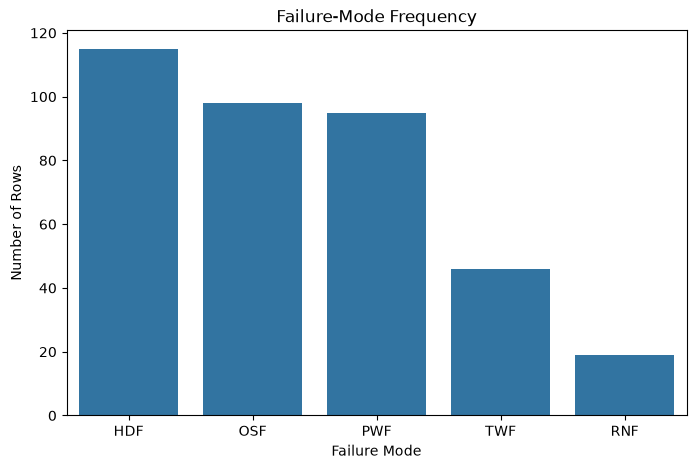

In [19]:
mode_counts = df[mode_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=mode_counts.index,
    y=mode_counts.values
)

plt.title("Failure-Mode Frequency")
plt.xlabel("Failure Mode")
plt.ylabel("Number of Rows")

plt.show()

In [20]:
rule_columns = {
    "HDF": "predicted_HDF",
    "PWF": "predicted_PWF",
    "OSF": "predicted_OSF"
}

rows = []

for mode, rule_col in rule_columns.items():

    actual_mode = df[mode] == 1
    detected_by_rule = df[rule_col]

    mode_count = actual_mode.sum()

    if mode_count > 0:
        coverage = (
            (actual_mode & detected_by_rule).sum()
            / mode_count
            * 100
        )
    else:
        coverage = np.nan

    rows.append({
        "mode": mode,
        "dataset_flag_count": int(mode_count),
        "rule_detected_count": int(
            (actual_mode & detected_by_rule).sum()
        ),
        "coverage_percent": coverage
    })

per_mode_rule_coverage = pd.DataFrame(rows)

per_mode_rule_coverage

,mode,dataset_flag_count,rule_detected_count,coverage_percent
0,HDF,115,115,100.0
1,PWF,95,95,100.0
2,OSF,98,98,100.0


In [21]:
twf_rnf_summary = pd.DataFrame({
    "TWF": [
        df["TWF"].sum(),
        ((df["TWF"] == 1) & (df["Machine failure"] == 1)).sum()
    ],
    "RNF": [
        df["RNF"].sum(),
        ((df["RNF"] == 1) & (df["Machine failure"] == 1)).sum()
    ]
}, index=[
    "mode_flag_count",
    "also_machine_failure"
])

twf_rnf_summary

,TWF,RNF
mode_flag_count,46,19
also_machine_failure,46,1


In [22]:
from pathlib import Path

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

rule_summary = pd.DataFrame({
    "rule": ["HDF", "PWF", "OSF"],
    "dataset_flag_count": [
        df["HDF"].sum(),
        df["PWF"].sum(),
        df["OSF"].sum()
    ],
    "matching_rows": [
        hdf_match.sum(),
        pwf_match.sum(),
        osf_match.sum()
    ],
    "mismatching_rows": [
        (~hdf_match).sum(),
        (~pwf_match).sum(),
        (~osf_match).sum()
    ],
    "match_percentage": [
        hdf_match.mean() * 100,
        pwf_match.mean() * 100,
        osf_match.mean() * 100
    ]
})

rule_summary.to_csv(
    REPORTS_DIR / "failure_rule_summary.csv",
    index=False
)

per_mode_rule_coverage.to_csv(
    REPORTS_DIR / "per_mode_rule_coverage.csv",
    index=False
)

unexplained_failures.to_csv(
    REPORTS_DIR / "rule_unexplained_failures.csv",
    index=False
)

mode_without_failure.to_csv(
    REPORTS_DIR / "mode_without_failure_label.csv",
    index=False
)

print("Reports saved successfully.")

Reports saved successfully.
